## Zadanie 1

Dla zbioru danych zamowienia.csv wykonaj:
- 1.1 Wczytaj dane i sprawdź czy są w nim wartości brakujące.
- 1.2 Zbiór z wartościami brakującymi zapisz do oddzielnej zmiennej.
- 1.3 W kolumnie Sprzedawca zastąp losowo 10% wartości wartością 'BRAK'. (zobacz funkcje pseudolosowe w bibliotece pandas lub numpy oraz wykorzystaj ćwiczenia z zajęć poprzednich z indeksowaniem danych w ramkach/seriach)
- 1.4 W kolumnie idZamowienia zastąp 5% wartości wartością np.nan.
- 1.5 W kolumnie Data zamówienia zastąp 20% wartości wartością np.nan.
- 1.6 W kolumnie Utarg zastąp 15% wartości wartością np.nan.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('zamowienia.csv', sep=';')
print("Czy w oryginalnym zbiorze są wartości brakujące?", df.isna().values.any())
df_missing = df.copy()

def wprowadz_braki(ramka, kolumna, procent, wartosc_zastepcza):
    liczba_wierszy = len(ramka)
    liczba_brakow = int(liczba_wierszy * procent)
    indeksy_do_zmiany = np.random.choice(ramka.index, size=liczba_brakow, replace=False)
    ramka.loc[indeksy_do_zmiany, kolumna] = wartosc_zastepcza

wprowadz_braki(df_missing, 'Sprzedawca', 0.10, 'BRAK')
wprowadz_braki(df_missing, 'idZamowienia', 0.05, np.nan)
wprowadz_braki(df_missing, 'Data zamowienia', 0.20, np.nan) # Zwróć uwagę na brak "ó"!
wprowadz_braki(df_missing, 'Utarg', 0.15, np.nan)

print("\nPodsumowanie wygenerowanych brakow:")
print(df_missing.isna().sum())

Czy w oryginalnym zbiorze są wartości brakujące? False

Podsumowanie wygenerowanych brakow:
Kraj                 0
Sprzedawca           0
Data zamowienia    159
idZamowienia        39
Utarg              119
dtype: int64


## Zadanie 2

Dla nowego zbioru (z wartościami brakującymi) z zadania 1 wykonaj:
- 2.1 Zastąp wartości brakujące w kolumnie idZamowienia wartością 0.
- 2.2 Zastąp wartości brakujące w kolumnie Data zamówienia wartościami w przód (ffill()).
- 2.3 Zastąp wartości brakujące w kolumnie Utarg wartością średnią dla danego kraju.

In [12]:
# 2.1
df_missing['idZamowienia'] = df_missing['idZamowienia'].fillna(0)

# 2.2
df_missing['Data zamowienia'] = df_missing['Data zamowienia'].ffill()

# 2.3
df_missing['Utarg'] = df_missing.groupby('Kraj')['Utarg'].transform(lambda x: x.fillna(x.mean()))

print("Sprawdzamy puste miejsca w 'Utarg' po operacji z 2.3:")
print(df_missing['Utarg'].isna().sum())

Sprawdzamy puste miejsca w 'Utarg' po operacji z 2.3:
0


## Zadanie 3

Wyświetl na wykresach typu histogram wraz z funkcją rozkładu (dokładnie tak jak w przykładach z wykładu) rozkłady cechy Utarg dla zbioru oryginalnego oraz tego po wykonaniu poleceń z zadania 2.

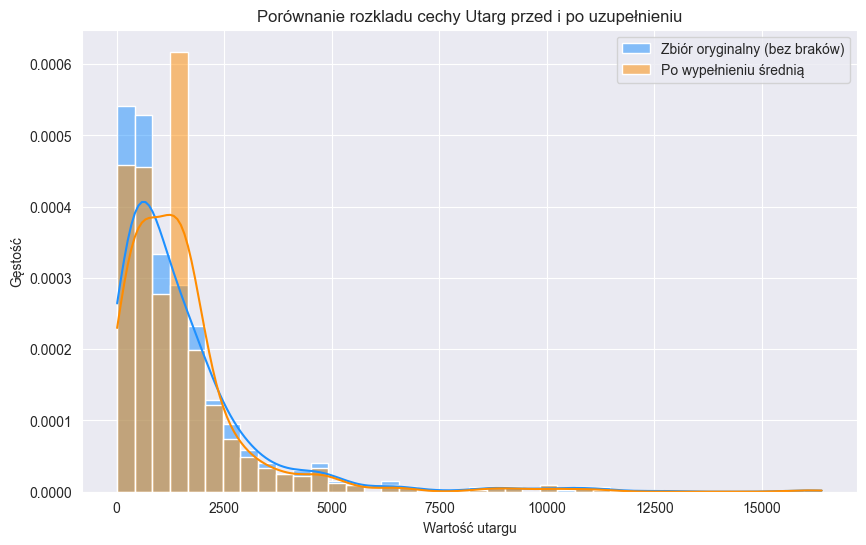

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Utarg'].dropna(), color='dodgerblue', alpha=0.5, kde=True, stat="density", label='Zbiór oryginalny (bez braków)', bins=40)

sns.histplot(df_missing['Utarg'].dropna(), color='darkorange', alpha=0.5, kde=True, stat="density", label='Po wypełnieniu średnią', bins=40)

plt.title('Porównanie rozkladu cechy Utarg przed i po uzupełnieniu')
plt.xlabel('Wartość utargu')
plt.ylabel('Gęstość')
plt.legend()
plt.show()

## Zadanie 4

Wykorzystując zbiór danych https://github.com/YBI-Foundation/Dataset/blob/main/Diabetes%20Missing%20Data.csv wykonaj imputację danych metodą KNN (przykład w materiałach z wykładu), ale stosując technikę group imputing czyli wyszukiwanie najbliższych sąsiadów odbywa się w danej grupie obiektów, a nie w całej populacji. Pamiętaj, że wykonujemy to dla cech numerycznych, więc pozostałe możesz póki co pomijać.

Przetestuj to rozwiązanie dla grup utworzonych dla cech:
- Class - tu będą dwie grupy
- Age - tutaj podział na grupy odbywa się na grupy: <18, 18_29, 30_49 i 50+ (możesz je utworzyć jako dodatkową kolumnę pomocniczą).
Po każdej imputacji porównaj rozkład zbioru oryginalnego i uzupełnionego jak w przykładach na wykładzie.

Wskazówki:
- grupy można stworzyć za pomocą wbudowanej funkcji groupby biblioteki pandas i zaaplikować imputer na każdej grupie,
- możesz wytrenować i zaaplikować imputer jednocześnie dla danej grupy (metoda fit_transform w większości przypadków wykorzystania biblioteki scikit-learn).
Pamiętaj o tym, że jest to tylko ćwiczenie, a w realnym scenariuszu najpierw dokonamy podziału na abiory train i test jeżeli jest to operacja mająca na celu przygotowanie danych do treningu modelu ML!

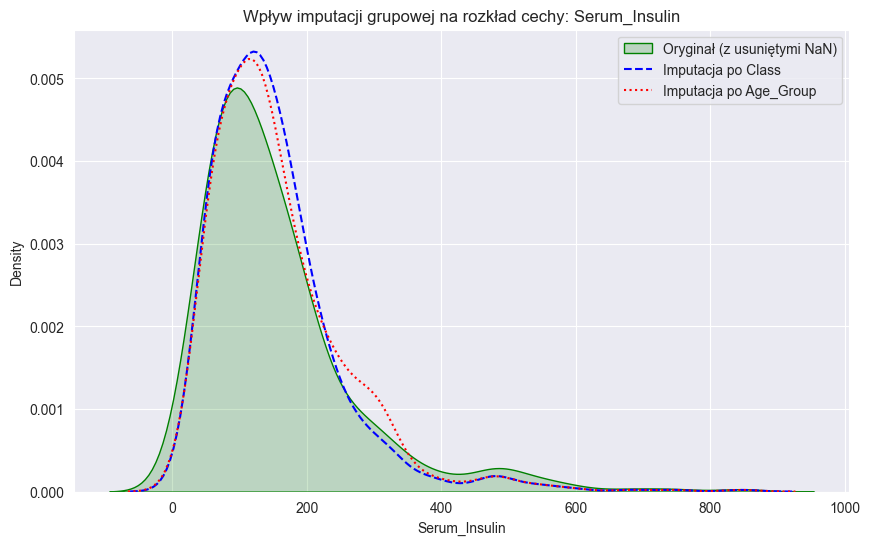

In [15]:
from sklearn.impute import KNNImputer

url_diabetes = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/refs/heads/main/Diabetes%20Missing%20Data.csv'
df_diab = pd.read_csv(url_diabetes)

imputer = KNNImputer(n_neighbors=5)
numeric_cols = df_diab.select_dtypes(include=np.number).columns

def group_impute(ramka, kolumna_grupujaca, kolumny_numeryczne):
    df_out = ramka.copy()
    for nazwa_grupy, dane_grupy in ramka.groupby(kolumna_grupujaca):
        imputed_data = imputer.fit_transform(dane_grupy[kolumny_numeryczne])
        df_out.loc[dane_grupy.index, kolumny_numeryczne] = imputed_data
    return df_out

df_imputed_class = group_impute(df_diab, 'Class', numeric_cols)


przedzialy = [0, 17, 29, 49, 150]
etykiety = ['<18', '18_29', '30_49', '50+']
df_diab['Age_Group'] = pd.cut(df_diab['Age'], bins=przedzialy, labels=etykiety)

df_imputed_age = group_impute(df_diab, 'Age_Group', numeric_cols)

cecha = 'Serum_Insulin'

plt.figure(figsize=(10, 6))
sns.kdeplot(df_diab[cecha].dropna(), color='green', label='Oryginał (z usuniętymi NaN)', fill=True, alpha=0.2)
sns.kdeplot(df_imputed_class[cecha], color='blue', label='Imputacja po Class', linestyle='--')
sns.kdeplot(df_imputed_age[cecha], color='red', label='Imputacja po Age_Group', linestyle=':')
plt.title(f'Wpływ imputacji grupowej na rozkład cechy: {cecha}')
plt.legend()
plt.show()